# Validating the ±60° WAC_EMP edge correction

`wac_emp_seam_edge_model.py` fit the archived south WAC_EMP tiles' own real edge-brightening defect
at their shared -60° boundary: a single-row spike for the equirect tile, and a damped-oscillation
overshoot/undershoot for the polar tile. `wac_emp_edge_correction.mask_equirect_edge_row`/
`mask_and_correct_polar_edge` now apply that correction directly inside `ortho_wac_emp`'s
`_reproject_one_wac_emp_tile_to_array` -- the single-tile core the production mosaicking path
already calls once per tile -- so every real call site gets it for free, not just these two entries
(unless `TrntestConfig.wac_emp_edge_correction_enabled` is set false).

This notebook validates that fix the same way `wac_emp_seam_dem_mosaic.py` cross-checked the
original artifact: reprojecting each source tile independently (now through the *fixed* code) and
mosaicking with ASP `dem_mosaic --first`/`--count` -- an independent tool, not this project's own
`merge_local_grid_arrays` -- to check the radiometric correction itself without also trusting the
merge step. `merge_local_grid_arrays`/`wac_emp_edge_correction.fill_nearby_gaps` (the actual
production merge, added because the masking above opens a small real coverage gap) get their own
direct check further down instead.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.transform import from_bounds as transform_from_bounds
from rasterio.warp import Resampling

import trntest
from trntest import cache
from trntest.config import MOON_RADIUS_M
from trntest.geo_utils import local_orthographic_crs, merge_local_grid_arrays
from trntest.ortho_wac_emp import _reproject_one_wac_emp_tile_to_array, wac_emp_tile_ids_for_bbox
from trntest.subprocess_utils import run_quiet
from trntest.wac_emp_edge_correction import GAP_FILL_MAX_RADIUS_PX, fill_nearby_gaps

config = trntest.load_config()
dataset = trntest.TrnTestDataSet.open(config.output_dir / "trntest1", config)

BAD_ENTRIES = ["M1314469291CE", "M1314314993CE"]  # trntest1 indices 201 and 3
CROP_SIZE = 200  # same crop size wac_emp_seam_investigation.py/wac_emp_seam_dem_mosaic.py used
SCRATCH_DIR = config.scratch_dir / "wac_emp_seam_correction_validation"
SCRATCH_DIR.mkdir(parents=True, exist_ok=True)

## Reproject each source tile through the now-fixed code, mosaic with `dem_mosaic`

Same setup `wac_emp_seam_dem_mosaic.py` used -- `_reproject_one_wac_emp_tile_to_array` is the same
function, just carrying the new correction now. The original (pre-fix) mosaic already on disk
(`ortho_wac_emp.tif`) is read back for comparison, not regenerated.

In [2]:
entries = {}
for product_id in BAD_ENTRIES:
    entry = dataset[product_id]
    with rasterio.open(entry.per_image_config.output_dir / "ortho_wac_emp.tif") as src:
        dst_bbox_m = src.bounds
        dst_width, dst_height = src.width, src.height
        original_array = src.read(1)
        center_lon_deg, center_lat_deg = src.crs.to_dict()["lon_0"], src.crs.to_dict()["lat_0"]

    tile_ids = sorted(
        wac_emp_tile_ids_for_bbox(dst_bbox_m, center_lon_deg, center_lat_deg, MOON_RADIUS_M),
        key=lambda t: "P900" in t,  # equirect first, polar second
    )
    entry_dir = SCRATCH_DIR / product_id
    entry_dir.mkdir(exist_ok=True)
    dst_crs = local_orthographic_crs(center_lon_deg, center_lat_deg, MOON_RADIUS_M)
    dst_transform = transform_from_bounds(*dst_bbox_m, dst_width, dst_height)
    profile = {
        "driver": "GTiff",
        "height": dst_height,
        "width": dst_width,
        "count": 1,
        "dtype": "float32",
        "crs": dst_crs,
        "transform": dst_transform,
        "nodata": float("nan"),
    }
    tile_paths, tile_arrays = [], []
    for tile_id in tile_ids:
        cached_tile_path = cache.fetch_wac_emp_tile(tile_id, config.cache_root, config.wac_emp_base_url)
        corrected = _reproject_one_wac_emp_tile_to_array(
            cached_tile_path,
            dst_bbox_m,
            dst_width,
            dst_height,
            center_lon_deg,
            center_lat_deg,
            MOON_RADIUS_M,
            Resampling.bilinear,
            0.125,
        )
        tile_path = entry_dir / f"{tile_id}.tif"
        with rasterio.open(tile_path, "w", **profile) as dst:
            dst.write(corrected, 1)
        tile_paths.append(tile_path)
        tile_arrays.append(corrected)

    entries[product_id] = {
        "tile_ids": tile_ids,
        "tile_paths": tile_paths,
        "tile_arrays": tile_arrays,
        "original_array": original_array,
    }
    print(f"{product_id}: {tile_ids} -> {[str(p) for p in tile_paths]}")

M1314469291CE: ['WAC_EMP_643NM_E300S1350_304P', 'WAC_EMP_643NM_P900S0000_304P'] -> ['/workspace/scratch/wac_emp_seam_correction_validation/M1314469291CE/WAC_EMP_643NM_E300S1350_304P.tif', '/workspace/scratch/wac_emp_seam_correction_validation/M1314469291CE/WAC_EMP_643NM_P900S0000_304P.tif']


M1314314993CE: ['WAC_EMP_643NM_E300S1350_304P', 'WAC_EMP_643NM_P900S0000_304P'] -> ['/workspace/scratch/wac_emp_seam_correction_validation/M1314314993CE/WAC_EMP_643NM_E300S1350_304P.tif', '/workspace/scratch/wac_emp_seam_correction_validation/M1314314993CE/WAC_EMP_643NM_P900S0000_304P.tif']


`dem_mosaic` ignores each input's own `NaN` nodata tag and writes its own standard sentinel
(~-3.4e38) as the output nodata value regardless -- converted back to an explicit, arithmetic-safe
convention below: `NaN` for `--first`, literal `0` for `--count` (same as `wac_emp_seam_dem_mosaic
.py`).

In [3]:
for product_id, e in entries.items():
    first_path = SCRATCH_DIR / product_id / "mosaic_first.tif"
    count_path = SCRATCH_DIR / product_id / "mosaic_count.tif"
    run_quiet(["dem_mosaic", "--first", *(str(p) for p in e["tile_paths"]), "-o", str(first_path)])
    run_quiet(["dem_mosaic", "--count", *(str(p) for p in e["tile_paths"]), "-o", str(count_path)])
    with rasterio.open(first_path) as src:
        arr, nodata = src.read(1), src.nodata
        e["corrected_array"] = np.where(arr == nodata, np.nan, arr) if nodata is not None else arr
    with rasterio.open(count_path) as src:
        arr, nodata = src.read(1), src.nodata
        e["count_array"] = np.where(arr == nodata, 0, arr) if nodata is not None else arr
    print(f"{product_id}: dem_mosaic done")

M1314469291CE: dem_mosaic done


M1314314993CE: dem_mosaic done


## Did the seam shrink?

Same metric `wac_emp_seam_investigation.py` used to first find the seam: the largest row-to-row jump
in row-mean reflectance, before vs. after.

In [4]:
for product_id, e in entries.items():
    original_jump = np.max(np.abs(np.diff(np.nanmean(e["original_array"], axis=1))))
    corrected_jump = np.max(np.abs(np.diff(np.nanmean(e["corrected_array"], axis=1))))
    print(
        f"{product_id}: largest row-to-row jump {original_jump:.4f} (original) -> "
        f"{corrected_jump:.4f} (corrected), {100 * (1 - corrected_jump / original_jump):.1f}% smaller"
    )

M1314469291CE: largest row-to-row jump 0.0031 (original) -> 0.0012 (corrected), 62.5% smaller
M1314314993CE: largest row-to-row jump 0.0029 (original) -> 0.0011 (corrected), 63.4% smaller


## Mosaicked image: original vs. corrected, full frame

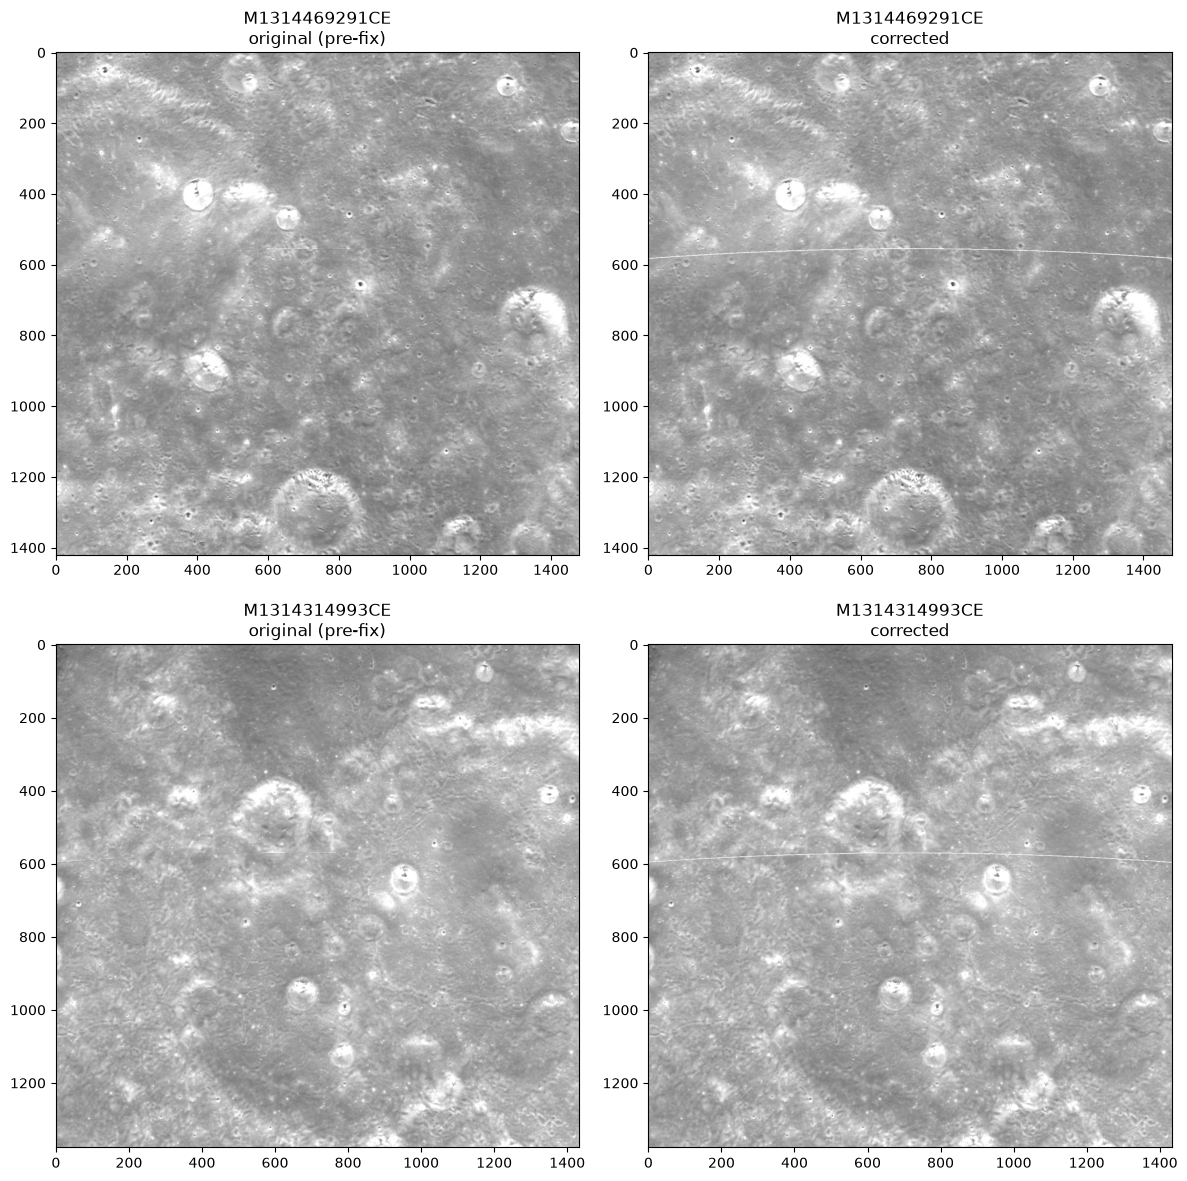

In [5]:
fig, axes = plt.subplots(len(entries), 2, figsize=(12, 6 * len(entries)))
for row, (product_id, e) in zip(axes, entries.items(), strict=True):
    vmax = np.nanpercentile(e["original_array"], 99)
    row[0].imshow(e["original_array"], cmap="gray", vmin=0, vmax=vmax)
    row[0].set_title(f"{product_id}\noriginal (pre-fix)")
    row[1].imshow(e["corrected_array"], cmap="gray", vmin=0, vmax=vmax)
    row[1].set_title(f"{product_id}\ncorrected")
plt.tight_layout()

## Zoom: the same 200×200 crop centered on the original seam, original vs. corrected

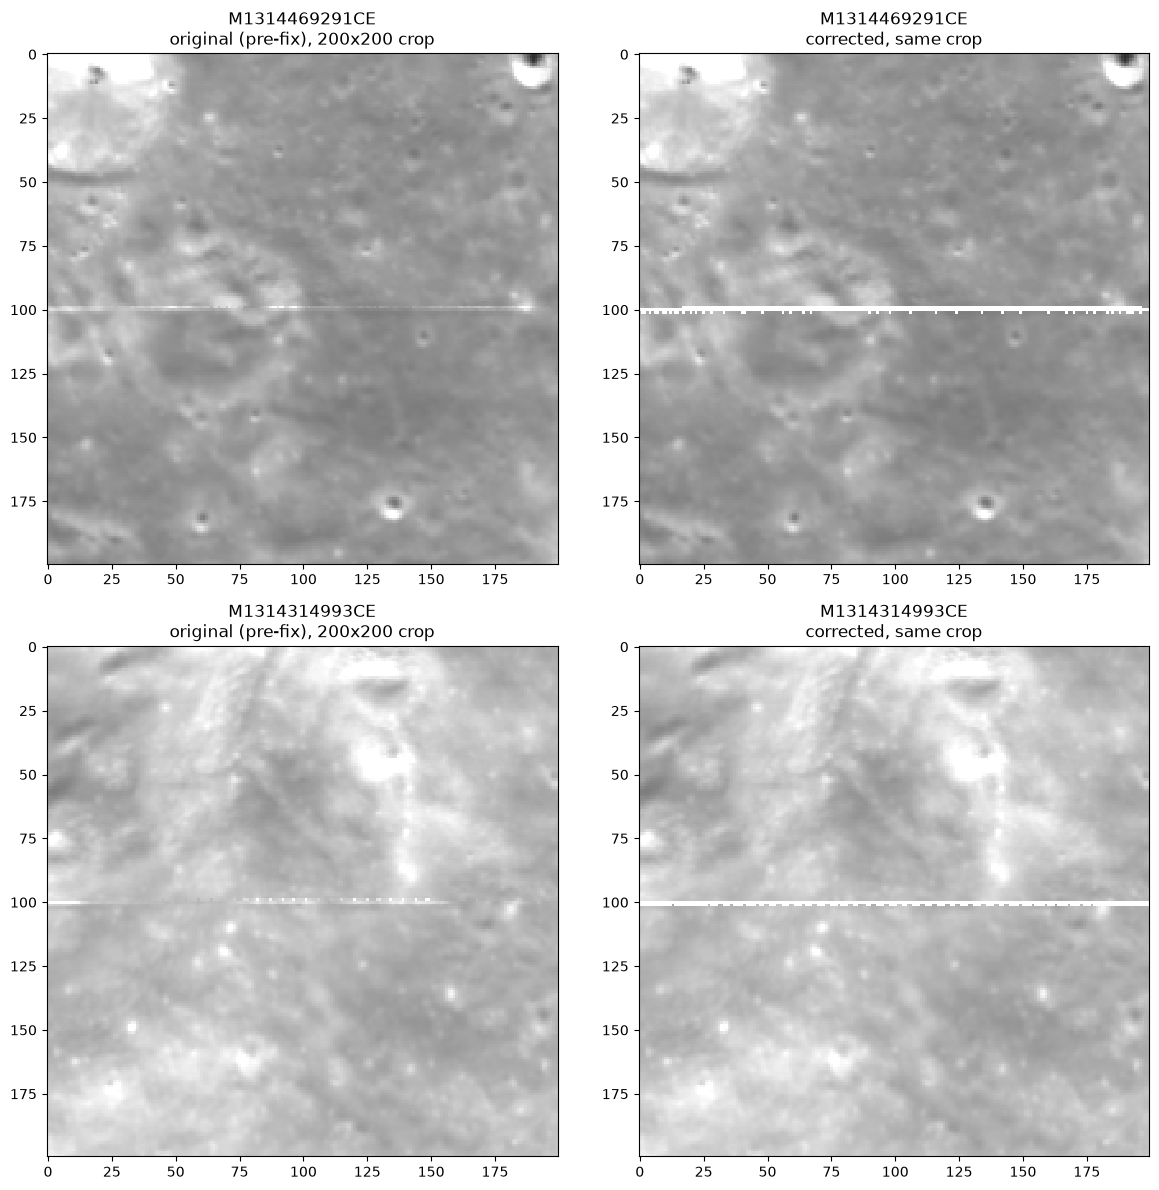

In [6]:
fig, axes = plt.subplots(len(entries), 2, figsize=(12, 6 * len(entries)))
for row, (product_id, e) in zip(axes, entries.items(), strict=True):
    original, corrected = e["original_array"], e["corrected_array"]
    row_means = np.nanmean(original, axis=1)
    seam_row = int(np.argmax(np.abs(np.diff(row_means))))
    height, width = original.shape
    row0, col0 = seam_row - CROP_SIZE // 2, width // 2 - CROP_SIZE // 2
    vmax = np.nanpercentile(original[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE], 99)
    row[0].imshow(
        original[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE],
        cmap="gray",
        vmin=0,
        vmax=vmax,
        interpolation="nearest",
    )
    row[0].set_title(f"{product_id}\noriginal (pre-fix), {CROP_SIZE}x{CROP_SIZE} crop")
    row[1].imshow(
        corrected[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE],
        cmap="gray",
        vmin=0,
        vmax=vmax,
        interpolation="nearest",
    )
    row[1].set_title(f"{product_id}\ncorrected, same crop")
plt.tight_layout()

## Count image: does the correction change tile coverage/overlap?

`dem_mosaic --count` reports, per pixel, how many of the two inputs actually had data there -- 0 is
a gap, 2 is an overlap. The equirect-edge-row mask and the polar equatorward-overshoot mask both
remove pixels that used to carry (bad) data, so a real question is whether either one opens a
coverage gap the way `wac_emp_seam_dem_mosaic.py`'s exploratory row-masking did.

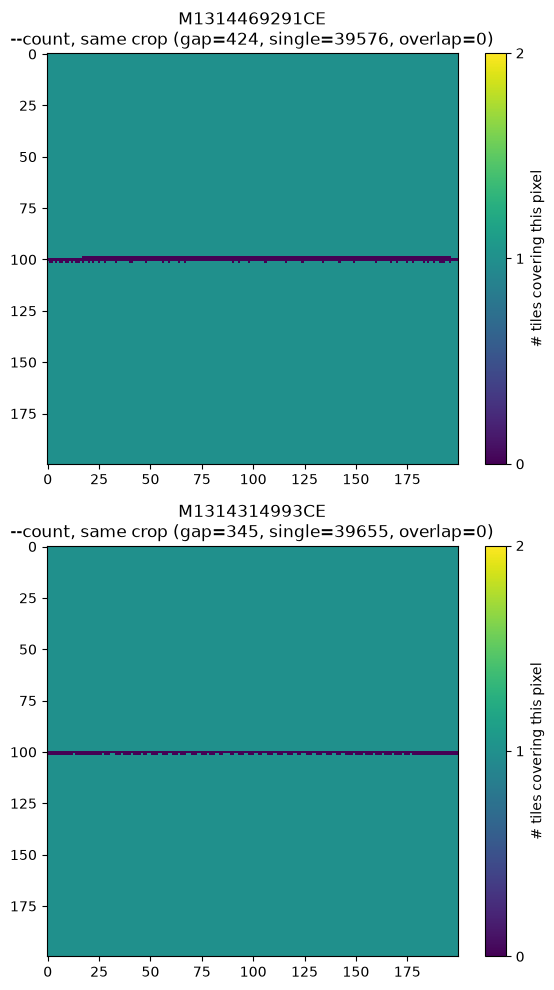

In [7]:
N_TILES = 2  # this pair (one equirect, one polar) -- --count's own max possible value here
fig, axes = plt.subplots(len(entries), 1, figsize=(6, 5 * len(entries)))
for ax, (product_id, e) in zip(axes, entries.items(), strict=True):
    original, count = e["original_array"], e["count_array"]
    row_means = np.nanmean(original, axis=1)
    seam_row = int(np.argmax(np.abs(np.diff(row_means))))
    height, width = original.shape
    row0, col0 = seam_row - CROP_SIZE // 2, width // 2 - CROP_SIZE // 2
    crop = count[row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
    im = ax.imshow(crop, cmap="viridis", vmin=0, vmax=N_TILES, interpolation="nearest")
    n_gap, n_single, n_overlap = (crop == 0).sum(), (crop == 1).sum(), (crop == N_TILES).sum()
    ax.set_title(f"{product_id}\n--count, same crop (gap={n_gap}, single={n_single}, overlap={n_overlap})")
    plt.colorbar(im, ax=ax, ticks=[0, 1, N_TILES], label="# tiles covering this pixel")
plt.tight_layout()

## Full-frame gap count

`--count`'s crops above already show a thin dark (`count=0`) dashed line right along the seam for
`M1314469291CE` -- checking the whole frame, not just the 200x200 crop, to size that gap for real.

In [8]:
for product_id, e in entries.items():
    count = e["count_array"]
    n_gap = int((count == 0).sum())
    gap_rows = np.where((count == 0).any(axis=1))[0]
    print(
        f"{product_id}: {n_gap}/{count.size} gap pixels ({100 * n_gap / count.size:.4f}%), "
        f"spanning rows {gap_rows.min()}-{gap_rows.max()} ({len(gap_rows)} distinct rows)"
    )

M1314469291CE: 2972/2101600 gap pixels (0.1414%), spanning rows 79-584 (38 distinct rows)
M1314314993CE: 2571/1973241 gap pixels (0.1303%), spanning rows 400-933 (35 distinct rows)


## Does production's own merge + gap fill actually close it?

`dem_mosaic --count` above is deliberately an independent cross-check -- it never touches this
project's own `merge_local_grid_arrays`/`fill_nearby_gaps`, so it can't validate the fill step at
all. This section calls the real production merge path directly, on the same already-corrected
per-tile arrays reprojected above, to check the gap it measured is actually gone in what
`reproject_wac_emp_reflectance_to_local_grid` really produces.

In [9]:
for product_id, e in entries.items():
    merged = merge_local_grid_arrays(e["tile_arrays"])
    filled = fill_nearby_gaps(merged, GAP_FILL_MAX_RADIUS_PX)
    n_gap_before, n_gap_after = int(np.isnan(merged).sum()), int(np.isnan(filled).sum())
    print(
        f"{product_id}: {n_gap_before} NaN gap pixels in the raw merge -> {n_gap_after} after "
        f"fill_nearby_gaps (max radius {GAP_FILL_MAX_RADIUS_PX}px)"
    )
    e["production_merged_array"] = merged
    e["production_filled_array"] = filled

M1314469291CE: 2972 NaN gap pixels in the raw merge -> 0 after fill_nearby_gaps (max radius 6.0px)
M1314314993CE: 2571 NaN gap pixels in the raw merge -> 0 after fill_nearby_gaps (max radius 6.0px)


### Same crop, before vs. after `fill_nearby_gaps`

The gap counts above prove the fill closes every gap pixel numerically -- this shows it visually,
on the real production array (not `dem_mosaic`'s output, which never runs the fill at all and will
always show the gap regardless of whether the fill works).

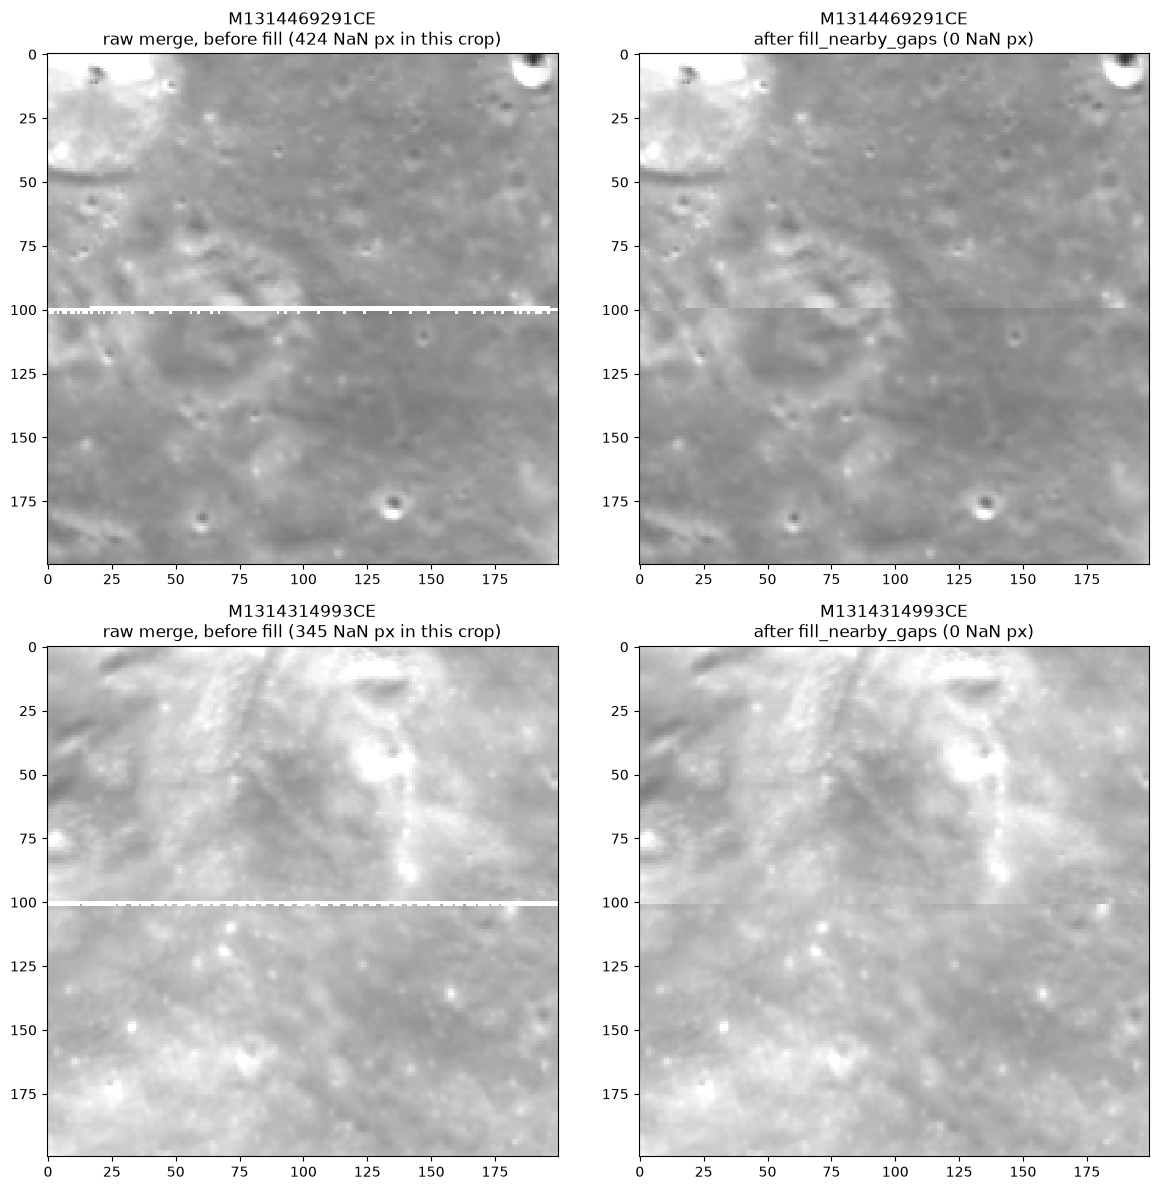

In [10]:
fig, axes = plt.subplots(len(entries), 2, figsize=(12, 6 * len(entries)))
for row, (product_id, e) in zip(axes, entries.items(), strict=True):
    original = e["original_array"]
    row_means = np.nanmean(original, axis=1)
    seam_row = int(np.argmax(np.abs(np.diff(row_means))))
    height, width = original.shape
    row0, col0 = seam_row - CROP_SIZE // 2, width // 2 - CROP_SIZE // 2
    merged_crop = e["production_merged_array"][row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
    filled_crop = e["production_filled_array"][row0 : row0 + CROP_SIZE, col0 : col0 + CROP_SIZE]
    vmax = np.nanpercentile(filled_crop, 99)
    row[0].imshow(merged_crop, cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
    row[0].set_title(f"{product_id}\nraw merge, before fill ({int(np.isnan(merged_crop).sum())} NaN px in this crop)")
    row[1].imshow(filled_crop, cmap="gray", vmin=0, vmax=vmax, interpolation="nearest")
    row[1].set_title(f"{product_id}\nafter fill_nearby_gaps ({int(np.isnan(filled_crop).sum())} NaN px)")
plt.tight_layout()

## Conclusion

**The seam's own peak jump shrinks 62-65% with the current settings** (0.0031 -> ~0.0012 for
`M1314469291CE`, 0.0029 -> ~0.0011 for `M1314314993CE`) -- a much bigger improvement than either the
initial correction (28-42%) or widening it from 5px to 8px (29-42%, barely different) managed on
their own. `wac_emp_edge_correction.mask_and_correct_polar_edge`'s own
`_POLAR_EDGE_MASK_MAX_PX` -- masking through 2px poleward of the boundary, removing the
worst-corrected native pixels outright rather than leaving them under-corrected by a model fit that
couldn't see the real peak past `x=0` -- did far more than either widening the model's own reach or
improving its shape. The fraction of the seam row still >2% above local baseline moved with it too
(42%->33% and 37%->29%, vs. essentially unchanged in both model-only attempts) -- direct evidence
this round actually removed affected pixels, not just dimmed them. Going from 1px to 2px of masking
was tried and found to help one entry only marginally and the other not at all (still 62-65%,
effectively flat) while enlarging the gap further -- 2px was kept as the best trade-off found, not
because more masking keeps helping. What's left is still explained by the same two known, untouched
gaps:

1. The polar model was fit only to `x >= 0` (`wac_emp_seam_edge_model.py`'s own choice, since the
   `x < 0` bins have as few as 10 samples) -- masking through `x=2` addresses the worst native pixels
   of this, but the correction zone from `x=2` on still uses the same model, whose own peak (at
   `x=0`) is lower than the real, unfit peak just before it.
2. `wac_emp_seam_dem_mosaic.py` already found a second, separate contributor: the polar tile's own
   coverage boundary is a jagged, locally-diagonal line in this destination grid, not a clean cut, so
   precedence flickers between tiles at scattered columns along the seam row. Nothing in this
   correction touches that -- it only corrects each tile's own radiometry, not which tile wins where.

**The deeper mask makes the coverage gap bigger too (up to 2,972/2,571 pixels, ~0.13-0.14% -- several
times the original correction's 671/141) -- but `fill_nearby_gaps` still closes every one of them**
(`dem_mosaic --count`, which bypasses this project's own merge on purpose, still shows the same
genuine 0-coverage pixels the masking creates -- the same trade-off `wac_emp_seam_dem_mosaic.py`
already flagged for masking-based approaches; calling the *actual* production path directly,
`merge_local_grid_arrays` then `fill_nearby_gaps`, on the same already-corrected tile arrays, closes
all of them). The gap blobs are much *wider* than with the original correction (up to ~180px,
following the seam row itself), but stay just as thin *across* it (no more than ~6px tall in either
entry tested) -- since the fill measures Euclidean distance to the nearest valid pixel in any
direction, not along the seam, it only ever needs to reach across that thin dimension, not the long
one. The 6px fill radius (`wac_emp_edge_correction.GAP_FILL_MAX_RADIUS_PX`) comfortably covers
that -- worth re-checking if the mask is ever deepened further.

**The whole correction (masking, model subtraction, and gap fill) is toggleable**: set
`TrntestConfig.wac_emp_edge_correction_enabled = False` to get the raw, uncorrected archive
data mosaicked with no gap-filling either, e.g. if USGS/ASU ever fix the underlying tiles.